In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
df = pd.read_csv("D:\\My DS Project\\Uber-Stock-Market-Analysis\\Data\\UBER.csv")

In [3]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

# Feature Selection

In [4]:
X = df[['Open', 'High', 'Low']]
y = df['Close']


# Train-Test Split

In [5]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Model 1: Linear Regression

In [6]:
lr = LinearRegression()
lr.fit(X_train,y_train)
pred_lr = lr.predict(X_test)


In [7]:
print("R2 Score :",r2_score(y_test,pred_lr))

print("MAE :",mean_absolute_error(y_test,pred_lr))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_lr)))

R2 Score : 0.9962664524915699
MAE : 0.39211789479838666
RMSE : 0.569003045135001


# Model 2: Random Forest

In [8]:
rf = RandomForestRegressor(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
pred_rf = rf.predict(X_test)

In [9]:
print("R2 :",r2_score(y_test,pred_rf))

print("MAE :",mean_absolute_error(y_test,pred_rf))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_rf)))

R2 : 0.995129108925409
MAE : 0.48269604651724723
RMSE : 0.6499170919842048


# Model 3: Gradient Boosting

In [10]:
gb = GradientBoostingRegressor()
gb.fit(X_train,y_train)
pred_gb = gb.predict(X_test)

In [11]:
print("R2 :",r2_score(y_test,pred_gb))

print("MAE :",mean_absolute_error(y_test,pred_gb))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_gb)))

R2 : 0.9948896139993751
MAE : 0.5154454945961232
RMSE : 0.6657031347226001


# Compare Models

In [12]:
models = pd.DataFrame({

"Model":[
"Linear Regression",
"Random Forest",
"Gradient Boosting"
],

"R2":[

r2_score(y_test,pred_lr),

r2_score(y_test,pred_rf),

r2_score(y_test,pred_gb)

]

})

models

,Model,R2
0,Linear Regression,0.996266
1,Random Forest,0.995129
2,Gradient Boosting,0.994890


# Actual vs Prediction

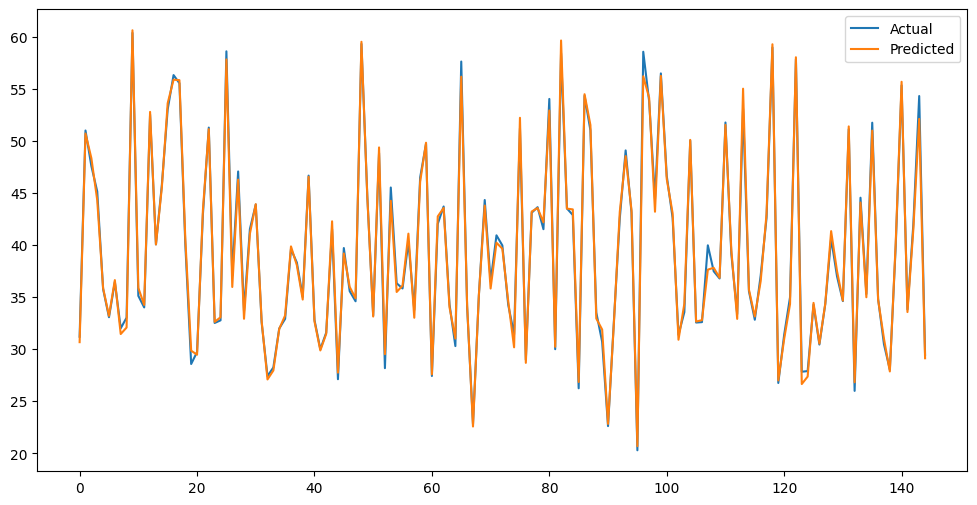

In [13]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values,label="Actual")

plt.plot(pred_rf,label="Predicted")

plt.legend()

plt.show()

# Feature Importance

In [14]:
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance.sort_values(
"Importance",
ascending=False
)

,Feature,Importance
1,High,0.645716
2,Low,0.304655
0,Open,0.049629


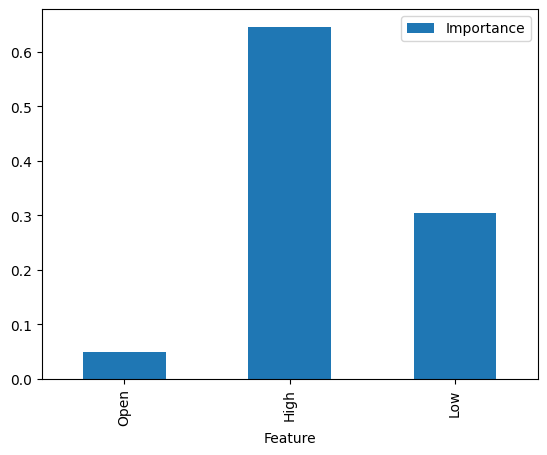

In [15]:
importance.plot(
x='Feature',
y='Importance',
kind='bar'
)

plt.show()

In [20]:
import joblib
joblib.dump(rf, "uber_stock_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!
